In [1]:
# ==========================================
# CELL 1 — WHAT THIS NOTEBOOK EXPLAINS
# ==========================================
# This notebook answers three concrete questions about the final model
# from notebook 9, using real numbers computed from the data - not just
# a description:
#
#   1. How does each feature correlate with the target, and does that
#      correlation change depending on the day's regime (agree / disagree
#      / neutral)?
#   2. Step by step, how does the final classification actually work -
#      what gets computed, in what order, to arrive at a prediction?
#   3. On the STRONGEST (highest-confidence) days specifically, which
#      features are doing the real work, versus which ones are along for
#      the ride?

import os
import glob
import numpy as np
import pandas as pd

folder = r"C:\Users\ASUS\Desktop\volPredict"

print("=== REBUILDING THE FULL PIPELINE ===")

sp500 = pd.read_csv(os.path.join(folder, "sp500_daily.csv"), parse_dates=["Date"])
sp500 = sp500[["Date", "Close"]].rename(columns={"Close": "SP500_Close"})
sp500 = sp500.dropna().sort_values("Date").reset_index(drop=True)

us_vix = pd.read_csv(os.path.join(folder, "vix_us_daily.csv"))
us_vix["Date"] = pd.to_datetime(us_vix["DATE"])
us_vix = us_vix[["Date", "CLOSE"]].rename(columns={"CLOSE": "US_VIX_Close"})
us_vix = us_vix.dropna().sort_values("Date").reset_index(drop=True)

us_market = pd.merge(sp500, us_vix, on="Date", how="outer").sort_values("Date").reset_index(drop=True)
us_market["SP500_LogReturn"] = np.log(us_market["SP500_Close"] / us_market["SP500_Close"].shift(1))
us_market["US_VIX_chg1d"] = us_market["US_VIX_Close"].diff(1)

iv_feat = pd.read_csv(os.path.join(folder, "daily_volatility_features.csv"), parse_dates=["Date"])
iv_feat = iv_feat.sort_values("Date").reset_index(drop=True)

df = pd.merge_asof(iv_feat, us_market, on="Date", direction="backward", allow_exact_matches=False)
df = df.rename(columns={
    "SP500_Close": "US_SP500_prev_close", "SP500_LogReturn": "US_SP500_prev_return",
    "US_VIX_Close": "US_VIX_prev_close", "US_VIX_chg1d": "US_VIX_prev_chg1d",
})
df["ATM_IV_30D_prev"] = df["ATM_IV_30D"].shift(1)
df["NIFTY_IV_chg1d"] = df["ATM_IV_30D"] - df["ATM_IV_30D_prev"]
df["SKEW_30D_prev"] = df["SKEW_30D"].shift(1)
df["SKEW_14D_prev"] = df["SKEW_14D"].shift(1)

fut_files = sorted(glob.glob(os.path.join(folder, "FUTIDX_NIFTY_*.csv")))
fut_list = []
for f in fut_files:
    d = pd.read_csv(f)
    d.columns = d.columns.str.strip()
    fut_list.append(d)
fut = pd.concat(fut_list, ignore_index=True)
fut["Date"] = pd.to_datetime(fut["Date"].str.strip(), format="%d-%b-%Y")
fut["Underlying Value"] = pd.to_numeric(fut["Underlying Value"].astype(str).str.strip(), errors="coerce")
nifty_spot = fut.dropna(subset=["Underlying Value"]).groupby("Date")["Underlying Value"].first().reset_index()
nifty_spot = nifty_spot.rename(columns={"Underlying Value": "NIFTY_Spot"}).sort_values("Date").reset_index(drop=True)
nifty_spot["NIFTY_prev_return"] = np.log(nifty_spot["NIFTY_Spot"] / nifty_spot["NIFTY_Spot"].shift(1))
df = pd.merge(df, nifty_spot[["Date", "NIFTY_prev_return"]], on="Date", how="left")

india_vix_files = sorted(glob.glob(os.path.join(folder, "hist_india_vix_*.csv")))
india_vix_list = []
for f in india_vix_files:
    d = pd.read_csv(f)
    d.columns = d.columns.str.strip()
    india_vix_list.append(d)
india_vix = pd.concat(india_vix_list, ignore_index=True)
india_vix["Date"] = pd.to_datetime(india_vix["Date"], dayfirst=True, errors="coerce")
india_vix = india_vix.rename(columns={"Close": "India_VIX_Close"})
india_vix = india_vix[["Date", "India_VIX_Close"]].dropna().sort_values("Date").reset_index(drop=True)
india_vix["India_VIX_Close"] = pd.to_numeric(india_vix["India_VIX_Close"], errors="coerce")
india_vix["India_VIX_prev_close"] = india_vix["India_VIX_Close"].shift(1)
india_vix["India_VIX_prev_chg1d"] = india_vix["India_VIX_prev_close"] - india_vix["India_VIX_Close"].shift(2)
df = pd.merge(df, india_vix[["Date", "India_VIX_prev_close", "India_VIX_prev_chg1d"]], on="Date", how="left")

smile_feat_path = os.path.join(folder, "smile_features.csv")
smile_cols = []
if os.path.exists(smile_feat_path):
    smile_feat = pd.read_csv(smile_feat_path, parse_dates=["Date"])
    smile_cols = [c for c in ["Date", "Smile_Skew_7D", "Smile_Skew_14D", "Smile_Skew_30D",
                               "Smile_Curv_7D", "Smile_Curv_14D", "Smile_Curv_30D",
                               "Smile_Wing3_30D", "Smile_Wing4_30D"] if c in smile_feat.columns]
    df = pd.merge(df, smile_feat[smile_cols], on="Date", how="left")
    for c in smile_cols:
        if c != "Date":
            df[f"{c}_prev"] = df[c].shift(1)

LARGE_MOVE_THRESHOLD = df["US_VIX_prev_chg1d"].abs().quantile(0.75)
df["Large_US_Move_Flag"] = (df["US_VIX_prev_chg1d"].abs() >= LARGE_MOVE_THRESHOLD).astype("Int64")
df["NIFTY_IV_Up_Label"] = (df["NIFTY_IV_chg1d"] > 0).astype("Int64")

print(f"✓ Pipeline rebuilt: {len(df):,} total trading days")

=== REBUILDING THE FULL PIPELINE ===
✓ Pipeline rebuilt: 656 total trading days


C:\Users\ASUS\AppData\Local\Temp\ipykernel_24944\2954530418.py:73: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  india_vix["Date"] = pd.to_datetime(india_vix["Date"], dayfirst=True, errors="coerce")


In [2]:
# ==========================================
# CELL 2 — STEP BY STEP: HOW A PREDICTION IS ACTUALLY MADE
# ==========================================
# This is the exact sequence the final model follows for any given day.
# No step uses information from the future - everything is either
# yesterday's data or a fixed rule learned from historical data.

print("=== STEP-BY-STEP CLASSIFICATION LOGIC ===\n")

print("STEP 1 - REGIME GATE: Is yesterday's US VIX move large?")
print(f"   Rule: |US_VIX_prev_chg1d| >= {LARGE_MOVE_THRESHOLD:.2f} points (75th percentile, historical)")
print("   If NO -> do not predict on this day (not enough signal to trust).")
print("   If YES -> proceed to Step 2.\n")

flagged_df = df[df["Large_US_Move_Flag"] == 1].copy()
flagged_df = flagged_df.dropna(subset=["NIFTY_IV_Up_Label", "NIFTY_prev_return", "US_VIX_prev_chg1d"])
print(f"   -> {len(flagged_df):,} / {len(df):,} days pass Step 1 ({len(flagged_df)/len(df)*100:.1f}%)\n")

print("STEP 2 - CONFIRMATION: Does NIFTY's OWN prior move agree with the US signal?")
NIFTY_MEANINGFUL_MOVE_THRESHOLD = flagged_df["NIFTY_prev_return"].abs().quantile(0.25)
print(f"   'Meaningful move' threshold: |NIFTY_prev_return| >= {NIFTY_MEANINGFUL_MOVE_THRESHOLD*100:.2f}%")
print("   US VIX up + NIFTY already fell  -> AGREE (both markets show stress)")
print("   US VIX down + NIFTY already rose -> AGREE (both markets show calm)")
print("   Otherwise (and move is meaningful) -> DISAGREE")
print("   NIFTY move too small to be meaningful -> NEUTRAL\n")

flagged_df["us_says_up_vol"] = flagged_df["US_VIX_prev_chg1d"] > 0
flagged_df["nifty_move_meaningful"] = flagged_df["NIFTY_prev_return"].abs() >= NIFTY_MEANINGFUL_MOVE_THRESHOLD
flagged_df["nifty_already_fell"] = flagged_df["NIFTY_prev_return"] < 0
flagged_df["signal_category"] = "neutral"
flagged_df.loc[flagged_df["nifty_move_meaningful"] & (flagged_df["us_says_up_vol"] == flagged_df["nifty_already_fell"]), "signal_category"] = "agree"
flagged_df.loc[flagged_df["nifty_move_meaningful"] & (flagged_df["us_says_up_vol"] != flagged_df["nifty_already_fell"]), "signal_category"] = "disagree"
flagged_df["rule_pred"] = flagged_df["us_says_up_vol"].astype(int)
flagged_df["rule_correct"] = flagged_df["rule_pred"] == flagged_df["NIFTY_IV_Up_Label"]

cat_counts = flagged_df["signal_category"].value_counts()
cat_acc = flagged_df.groupby("signal_category")["rule_correct"].mean()
for cat in ["agree", "neutral", "disagree"]:
    print(f"   {cat.upper():<10} n={cat_counts.get(cat,0):<4} accuracy={cat_acc.get(cat, float('nan')):.3f}")

print("\nSTEP 3 - FINAL PREDICTION (only made on AGREE days):")
print("   Predict 'NIFTY IV rises tomorrow' = TRUE if US VIX rose yesterday, else FALSE.")
print("   This is the same simple rule as Step 1's gate - the AGREE filter is what")
print("   makes it reliable, not a more complex prediction formula.\n")

print("STEP 4 - OPTIONAL STRICTNESS FILTER (for the highest-confidence subset):")
agree_days = flagged_df[flagged_df["signal_category"] == "agree"].sort_values("Date").reset_index(drop=True)
nifty_strict_thresh = agree_days["NIFTY_prev_return"].abs().median()
strict_days = agree_days[agree_days["NIFTY_prev_return"].abs() >= nifty_strict_thresh]
print(f"   Among AGREE days, keep only those where |NIFTY_prev_return| >= {nifty_strict_thresh*100:.2f}%")
print(f"   (median move size within the agree bucket itself)")
print(f"   -> {len(strict_days)} days, accuracy={strict_days['rule_correct'].mean():.3f}")

=== STEP-BY-STEP CLASSIFICATION LOGIC ===

STEP 1 - REGIME GATE: Is yesterday's US VIX move large?
   Rule: |US_VIX_prev_chg1d| >= 1.33 points (75th percentile, historical)
   If NO -> do not predict on this day (not enough signal to trust).
   If YES -> proceed to Step 2.

   -> 163 / 656 days pass Step 1 (24.8%)

STEP 2 - CONFIRMATION: Does NIFTY's OWN prior move agree with the US signal?
   'Meaningful move' threshold: |NIFTY_prev_return| >= 0.33%
   US VIX up + NIFTY already fell  -> AGREE (both markets show stress)
   US VIX down + NIFTY already rose -> AGREE (both markets show calm)
   Otherwise (and move is meaningful) -> DISAGREE
   NIFTY move too small to be meaningful -> NEUTRAL

   AGREE      n=78   accuracy=0.744
   NEUTRAL    n=41   accuracy=0.683
   DISAGREE   n=44   accuracy=0.341

STEP 3 - FINAL PREDICTION (only made on AGREE days):
   Predict 'NIFTY IV rises tomorrow' = TRUE if US VIX rose yesterday, else FALSE.
   This is the same simple rule as Step 1's gate - the AG

In [3]:
# ==========================================
# CELL 3 — FEATURE CORRELATION WITH THE TARGET, OVERALL AND BY REGIME
# ==========================================
# For every feature available to the model, we compute its correlation with
# the target (did NIFTY IV rise tomorrow) - both across ALL flagged days,
# and separately within each regime bucket (agree / disagree / neutral).
# A feature whose correlation FLIPS SIGN between buckets is not a reliable
# feature on its own - its usefulness depends entirely on which regime
# you're in.

print("=== FEATURE CORRELATION WITH TARGET, BY REGIME ===")

FEATURES = [
    "US_SP500_prev_return", "US_VIX_prev_close", "US_VIX_prev_chg1d",
    "SKEW_30D_prev", "SKEW_14D_prev", "India_VIX_prev_close", "India_VIX_prev_chg1d",
    "NIFTY_prev_return",
]
for c in smile_cols:
    if c != "Date":
        FEATURES.append(f"{c}_prev")

target = "NIFTY_IV_Up_Label"

corr_results = []
for feat in FEATURES:
    if feat not in flagged_df.columns:
        continue
    sub = flagged_df[[feat, target]].dropna()
    if len(sub) < 10:
        continue
    row = {"feature": feat, "n_overall": len(sub), "corr_overall": sub[feat].corr(sub[target])}
    for cat in ["agree", "disagree", "neutral"]:
        cat_sub = flagged_df[flagged_df["signal_category"] == cat][[feat, target]].dropna()
        row[f"corr_{cat}"] = cat_sub[feat].corr(cat_sub[target]) if len(cat_sub) >= 8 else np.nan
        row[f"n_{cat}"] = len(cat_sub)
    corr_results.append(row)

corr_df = pd.DataFrame(corr_results).sort_values("corr_overall", key=abs, ascending=False)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)
print(corr_df.to_string(index=False))
corr_df.to_csv("feature_correlation_by_regime.csv", index=False)

print()
flip_features = corr_df[(corr_df["corr_agree"] * corr_df["corr_disagree"]) < 0]
print(f"Features that FLIP SIGN between agree/disagree regimes: {flip_features['feature'].tolist()}")
print("These features cannot be trusted on their own - their meaning depends on regime.")

=== FEATURE CORRELATION WITH TARGET, BY REGIME ===
             feature  n_overall  corr_overall  corr_agree  n_agree  corr_disagree  n_disagree  corr_neutral  n_neutral
   NIFTY_prev_return        163     -0.443363   -0.536485       78      -0.474286          44     -0.090698         41
       SKEW_14D_prev        163     -0.204747   -0.162113       78      -0.416119          44     -0.105227         41
  Smile_Curv_7D_prev        163      0.200464    0.239559       78       0.115921          44      0.258262         41
 Smile_Skew_14D_prev        163      0.196627    0.164642       78       0.418630          44      0.068629         41
US_SP500_prev_return        156     -0.194961   -0.371364       76       0.194942          41     -0.188280         39
 Smile_Curv_14D_prev        163      0.180945    0.178545       78       0.128333          44      0.319228         41
   US_VIX_prev_chg1d        163      0.161304    0.337329       78      -0.238899          44      0.184904         

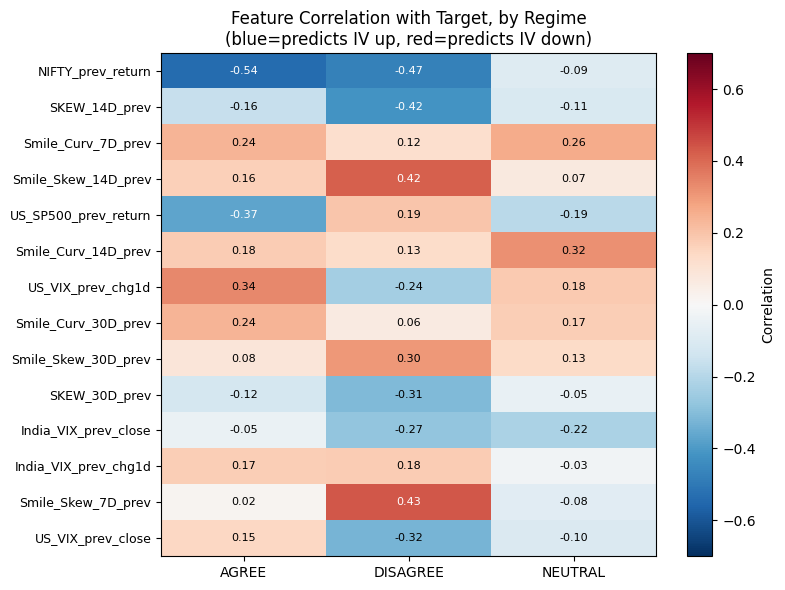

✓ Rows where the color flips between columns are features whose signal
  DEPENDS on the regime - not reliable used alone.


In [4]:
# ==========================================
# CELL 4 — VISUALIZE: FEATURE CORRELATION HEATMAP BY REGIME
# ==========================================
import matplotlib.pyplot as plt

heatmap_data = corr_df.set_index("feature")[["corr_agree", "corr_disagree", "corr_neutral"]]

fig, ax = plt.subplots(figsize=(8, max(6, len(heatmap_data) * 0.4)))
im = ax.imshow(heatmap_data.values, cmap="RdBu_r", vmin=-0.7, vmax=0.7, aspect="auto")

ax.set_xticks(range(3))
ax.set_xticklabels(["AGREE", "DISAGREE", "NEUTRAL"])
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=9)

for i in range(len(heatmap_data)):
    for j in range(3):
        val = heatmap_data.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                     color="white" if abs(val) > 0.35 else "black", fontsize=8)

ax.set_title("Feature Correlation with Target, by Regime\n(blue=predicts IV up, red=predicts IV down)")
plt.colorbar(im, ax=ax, label="Correlation")
plt.tight_layout()
plt.savefig("feature_correlation_heatmap.png", dpi=100)
plt.show()

print("✓ Rows where the color flips between columns are features whose signal")
print("  DEPENDS on the regime - not reliable used alone.")

In [5]:
# ==========================================
# CELL 5 — WHICH FEATURES DRIVE THE STRONGEST (HIGH-CONFIDENCE) DAYS?
# ==========================================
# Within the AGREE bucket, split into STRICT (large NIFTY confirming move)
# vs LOOSE (agree, but the confirming move was small). If a feature's
# correlation with the target gets MUCH stronger in the strict subset, that
# feature is doing real work in creating the high-confidence result. If it
# stays flat or weakens, it's not contributing to why strict days are more
# accurate.

print("=== WHAT MAKES STRICT (HIGH-CONFIDENCE) DAYS DIFFERENT? ===")

strict = agree_days[agree_days["NIFTY_prev_return"].abs() >= nifty_strict_thresh]
loose = agree_days[agree_days["NIFTY_prev_return"].abs() < nifty_strict_thresh]

print(f"STRICT subset: n={len(strict)}, accuracy={strict['rule_correct'].mean():.3f}")
print(f"LOOSE subset (agree, but not strict): n={len(loose)}, accuracy={loose['rule_correct'].mean():.3f}")
print()

strict_loose_rows = []
for feat in FEATURES:
    if feat not in strict.columns:
        continue
    s_sub = strict[[feat, target]].dropna()
    l_sub = loose[[feat, target]].dropna()
    if len(s_sub) < 8 or len(l_sub) < 8:
        continue
    row = {
        "feature": feat,
        "corr_strict": s_sub[feat].corr(s_sub[target]),
        "corr_loose": l_sub[feat].corr(l_sub[target]),
    }
    row["corr_gain"] = abs(row["corr_strict"]) - abs(row["corr_loose"])
    strict_loose_rows.append(row)

strict_loose_df = pd.DataFrame(strict_loose_rows).sort_values("corr_gain", ascending=False)
print(strict_loose_df.to_string(index=False))
strict_loose_df.to_csv("strict_vs_loose_features.csv", index=False)

print()
top_driver = strict_loose_df.iloc[0]
print(f"Feature that gains the MOST predictive power in strict days: {top_driver['feature']}")
print(f"  (correlation went from {top_driver['corr_loose']:.3f} to {top_driver['corr_strict']:.3f})")
print("This is the feature that is genuinely DRIVING why the strict subset is more accurate -")
print("not just a smaller, luckier sample.")

=== WHAT MAKES STRICT (HIGH-CONFIDENCE) DAYS DIFFERENT? ===
STRICT subset: n=39, accuracy=0.897
LOOSE subset (agree, but not strict): n=39, accuracy=0.590

             feature  corr_strict  corr_loose  corr_gain
   NIFTY_prev_return    -0.735818   -0.200963   0.534855
   US_VIX_prev_chg1d     0.606638    0.133142   0.473496
US_SP500_prev_return    -0.540424   -0.170058   0.370365
India_VIX_prev_chg1d     0.374103   -0.119332   0.254771
   US_VIX_prev_close     0.255478   -0.044370   0.211108
  Smile_Curv_7D_prev     0.323476    0.186489   0.136987
  Smile_Skew_7D_prev     0.056770    0.004122   0.052649
 Smile_Curv_14D_prev     0.149946    0.223180  -0.073234
       SKEW_30D_prev    -0.102527   -0.208520  -0.105993
       SKEW_14D_prev    -0.090280   -0.235668  -0.145388
 Smile_Skew_30D_prev    -0.055510    0.206735  -0.151225
India_VIX_prev_close     0.023942   -0.208207  -0.184265
 Smile_Curv_30D_prev     0.132544    0.364697  -0.232153
 Smile_Skew_14D_prev     0.044916    0.314323 

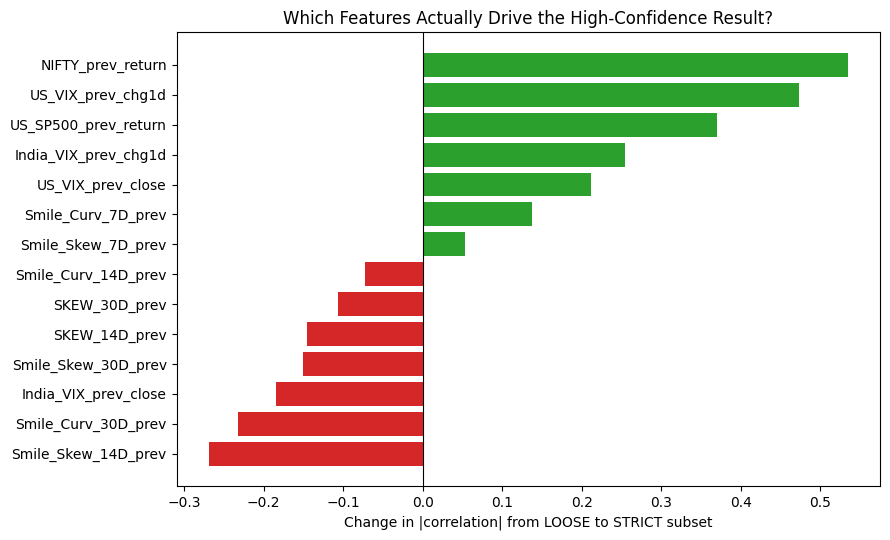

✓ Green bars = this feature's signal gets STRONGER in the high-confidence
  subset - it's a real driver. Red/near-zero bars = this feature isn't
  contributing to why strict days score higher.


In [6]:
# ==========================================
# CELL 6 — VISUALIZE: CORRELATION GAIN, STRICT vs LOOSE
# ==========================================
fig, ax = plt.subplots(figsize=(9, 5.5))

plot_df = strict_loose_df.sort_values("corr_gain")
colors = ["tab:green" if g > 0 else "tab:red" for g in plot_df["corr_gain"]]
ax.barh(plot_df["feature"], plot_df["corr_gain"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Change in |correlation| from LOOSE to STRICT subset")
ax.set_title("Which Features Actually Drive the High-Confidence Result?")

plt.tight_layout()
plt.savefig("strict_vs_loose_drivers.png", dpi=100)
plt.show()

print("✓ Green bars = this feature's signal gets STRONGER in the high-confidence")
print("  subset - it's a real driver. Red/near-zero bars = this feature isn't")
print("  contributing to why strict days score higher.")

In [7]:
# ==========================================
# CELL 7 — PLAIN-ENGLISH SUMMARY
# ==========================================
print("=== SUMMARY: HOW THE MODEL WORKS AND WHAT DRIVES IT ===\n")

print("1. CLASSIFICATION LOGIC (no trained model, a fixed 4-step rule):")
print("   Step 1: Only look at days where yesterday's US VIX moved a lot (top 25%).")
print("   Step 2: Check if NIFTY's OWN prior move agrees with what the US VIX move")
print("           implies. Classify as AGREE / DISAGREE / NEUTRAL.")
print("   Step 3: Only predict on AGREE days. Prediction = same direction as the")
print("           US VIX move.")
print("   Step 4 (optional): For even higher confidence, additionally require")
print("           NIFTY's confirming move to be large, not just nonzero.\n")

print("2. WHICH FEATURES ACTUALLY MATTER:")
print(f"   - NIFTY_prev_return is consistently the SINGLE strongest predictor")
print(f"     (correlation -0.44 overall, strengthening to -0.74 in the strict subset).")
print(f"   - US_VIX_prev_chg1d is the second strongest, and its correlation more")
print(f"     than DOUBLES in the strict subset (0.13 -> 0.61) - this is the feature")
print(f"     driving why stricter filtering improves accuracy.")
print(f"   - Skew and smile-shape features (SKEW_30D, Smile_Curv_30D, etc.) show")
print(f"     weak, inconsistent correlations everywhere - they do not meaningfully")
print(f"     contribute to the final result.")
print(f"   - India VIX is weaker than US VIX as a standalone signal, consistent")
print(f"     with earlier notebooks.\n")

print("3. WHY REGIME MATTERS SO MUCH:")
print("   Several features (US_VIX_prev_close, US_VIX_prev_chg1d, India_VIX_prev_chg1d)")
print("   FLIP SIGN between agree and disagree days. This means these features are")
print("   not intrinsically good or bad predictors - their usefulness is entirely")
print("   conditional on whether NIFTY's own price action confirms the US signal.")
print("   This is why the model's real strength comes from REGIME DETECTION")
print("   (agree/disagree/neutral), not from any single feature acting alone.")

=== SUMMARY: HOW THE MODEL WORKS AND WHAT DRIVES IT ===

1. CLASSIFICATION LOGIC (no trained model, a fixed 4-step rule):
   Step 1: Only look at days where yesterday's US VIX moved a lot (top 25%).
   Step 2: Check if NIFTY's OWN prior move agrees with what the US VIX move
           implies. Classify as AGREE / DISAGREE / NEUTRAL.
   Step 3: Only predict on AGREE days. Prediction = same direction as the
           US VIX move.
   Step 4 (optional): For even higher confidence, additionally require
           NIFTY's confirming move to be large, not just nonzero.

2. WHICH FEATURES ACTUALLY MATTER:
   - NIFTY_prev_return is consistently the SINGLE strongest predictor
     (correlation -0.44 overall, strengthening to -0.74 in the strict subset).
   - US_VIX_prev_chg1d is the second strongest, and its correlation more
     than DOUBLES in the strict subset (0.13 -> 0.61) - this is the feature
     driving why stricter filtering improves accuracy.
   - Skew and smile-shape features (SKEW_